=== CÁLCULO DA CURVA DE CAPITAL (EQUITY CURVE) Mínima Variância ===
1. A carregar os históricos e taxas externas...
2. A calcular os rendimentos da estratégia...
3. A descontar a fricção do Turnover (0.5%)...
4. A renderizar a evolução do património...


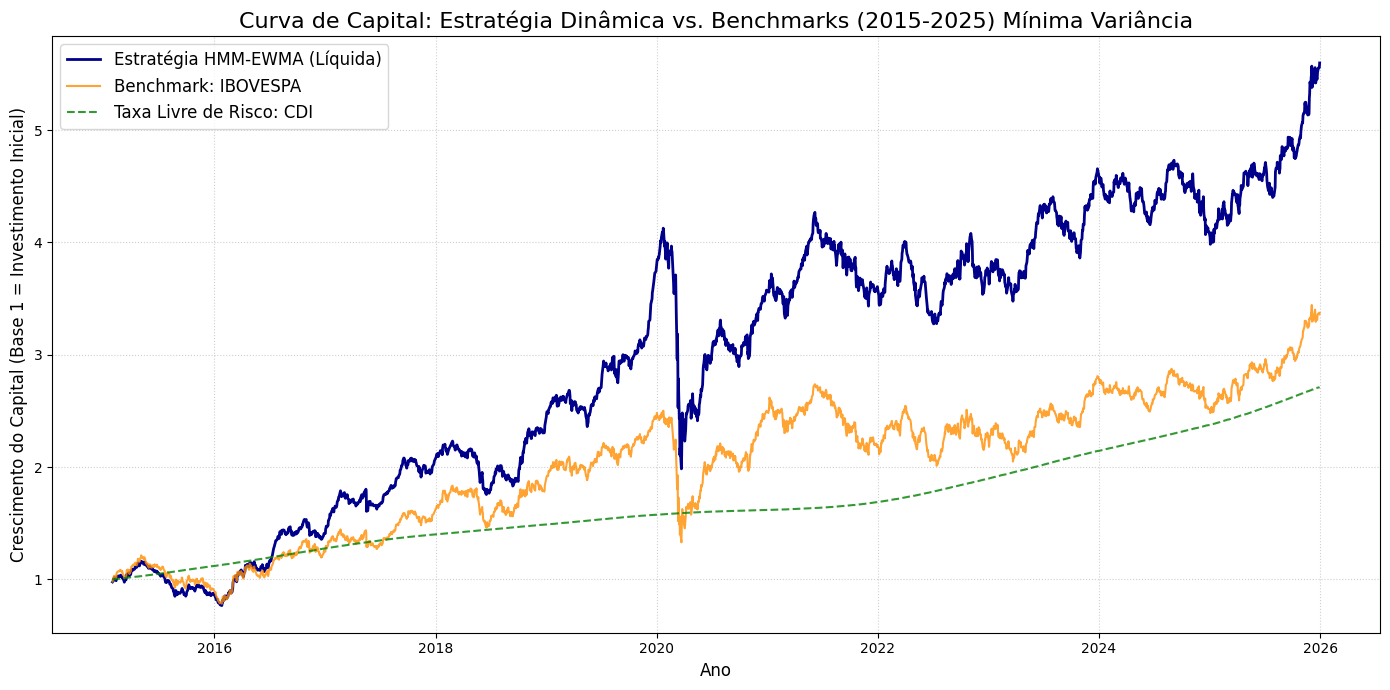


=== RESULTADO FINAL DO BACKTEST Mínima Variância ===
Período: 2015-01-30 a 2025-12-30
Rendimento Estratégia HMM: +459.81%
Rendimento IBOVESPA:       +237.35%
Rendimento CDI:            +171.22%
Gráfico salvo em: C:\VSCodeWorkspace\TCC_Escrito\data\curva_capital_backtest_minima_variancia.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def calcular_curva_capital(diretorio_dados):
    print("=== CÁLCULO DA CURVA DE CAPITAL (EQUITY CURVE) Mínima Variância ===")
    
    print("1. A carregar os históricos e taxas externas...")
    historico_pesos = pd.read_csv(os.path.join(diretorio_dados, "historico_alocacao_HMM_EWMA_minima_variancia.csv"), index_col=0, parse_dates=True)
    df_retornos = pd.read_csv(os.path.join(diretorio_dados, "matriz_retornos_simples_v2.csv"), index_col='Data', parse_dates=True)
    historico_turnover = pd.read_csv(os.path.join(diretorio_dados, "historico_turnover_minima_variancia.csv"), index_col=0, parse_dates=True)
    historico_turnover.columns = ['Turnover']
    
    # Carregamento Externo do CDI
    caminho_cdi = os.path.join(diretorio_dados, "CDI_2010_2026.xlsx")
    df_cdi = pd.read_excel(caminho_cdi)
    df_cdi = df_cdi.rename(columns={'Date': 'Data', 'valor': 'CDI'}).set_index('Data')
    df_cdi.index = pd.to_datetime(df_cdi.index)
    
    data_inicio = historico_pesos.index[0]
    df_retornos = df_retornos.loc[data_inicio:]
    
    pesos_diarios = historico_pesos.reindex(df_retornos.index).ffill()
    pesos_diarios = pesos_diarios.bfill() 
    
    print("2. A calcular os rendimentos da estratégia...")
    retornos_ativos = df_retornos[historico_pesos.columns]
    retorno_carteira_bruto = (retornos_ativos * pesos_diarios).sum(axis=1)
    
    print("3. A descontar a fricção do Turnover (0.5%)...")
    custo_transacional = 0.005 # 0.5%
    custos_diarios = pd.Series(0.0, index=retorno_carteira_bruto.index)
    custos_diarios.loc[historico_turnover.index] = historico_turnover['Turnover'] * custo_transacional
    
    retorno_carteira_liquido = retorno_carteira_bruto - custos_diarios
    
    print("4. A renderizar a evolução do património...")
    curva_estrategia = (1 + retorno_carteira_liquido).cumprod()
    curva_ibov = (1 + df_retornos['IBOV']).cumprod()

    # Alinhar CDI com os retornos e gerar a curva limpa
    cdi_alinhado = df_cdi['CDI'].reindex(df_retornos.index).ffill()
    curva_cdi = (1 + cdi_alinhado).cumprod()
    
    plt.figure(figsize=(14, 7))
    plt.plot(curva_estrategia, label='Estratégia HMM-EWMA (Líquida)', color='darkblue', linewidth=2)
    plt.plot(curva_ibov, label='Benchmark: IBOVESPA', color='darkorange', linewidth=1.5, alpha=0.8)
    plt.plot(curva_cdi, label='Taxa Livre de Risco: CDI', color='green', linewidth=1.5, linestyle='--', alpha=0.8)
    
    plt.title('Curva de Capital: Estratégia Dinâmica vs. Benchmarks (2015-2025) Mínima Variância', fontsize=16)
    plt.ylabel('Crescimento do Capital (Base 1 = Investimento Inicial)', fontsize=12)
    plt.xlabel('Ano', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    
    caminho_grafico = os.path.join(diretorio_dados, "curva_capital_backtest_minima_variancia.png")
    plt.savefig(caminho_grafico, dpi=300)
    plt.show()
    
    retorno_total_est = (curva_estrategia.iloc[-1] - 1) * 100
    retorno_total_ibov = (curva_ibov.iloc[-1] - 1) * 100
    retorno_total_cdi = (curva_cdi.iloc[-1] - 1) * 100
    
    print("\n=== RESULTADO FINAL DO BACKTEST Mínima Variância ===")
    print(f"Período: {data_inicio.date()} a {curva_estrategia.index[-1].date()}")
    print(f"Rendimento Estratégia HMM: +{retorno_total_est:.2f}%")
    print(f"Rendimento IBOVESPA:       +{retorno_total_ibov:.2f}%")
    print(f"Rendimento CDI:            +{retorno_total_cdi:.2f}%")
    print(f"Gráfico salvo em: {caminho_grafico}")
    print("===================================")

pasta_dados = r"C:\VSCodeWorkspace\TCC_Escrito\data"
calcular_curva_capital(pasta_dados)